# Veridi Logistics: Last Mile Delivery Audit
**Question:** Are we failing specific regions, or is this nationwide? Are our delivery estimates wrong?

In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.2f}".format)
os.makedirs("charts", exist_ok=True)

FILES = ["olist_orders_dataset.csv","olist_order_reviews_dataset.csv","olist_customers_dataset.csv",
         "olist_products_dataset.csv","olist_order_items_dataset.csv","product_category_name_translation.csv"]
missing = [f for f in FILES if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(f"Put these files next to this script: {missing}")

## Story 1: Schema Builder (load + joins, no duplicated rows)

In [2]:
date_cols = ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date",
             "order_delivered_customer_date","order_estimated_delivery_date"]
orders    = pd.read_csv("olist_orders_dataset.csv", parse_dates=date_cols)
reviews   = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
products  = pd.read_csv("olist_products_dataset.csv")
items     = pd.read_csv("olist_order_items_dataset.csv")
trans     = pd.read_csv("product_category_name_translation.csv")

for n,d in [("orders",orders),("reviews",reviews),("customers",customers),("products",products),("items",items)]:
    print(f"{n:10s} rows={len(d):>7,}")

# --- Duplicate-risk checks (1-to-many traps) ---
print("\nOrders with >1 review:", (reviews.groupby("order_id").size() > 1).sum())
print("customer_id unique in customers:", customers.customer_id.is_unique)

orders     rows= 99,441
reviews    rows= 99,224
customers  rows= 99,441
products   rows= 32,951
items      rows=112,650

Orders with >1 review: 547
customer_id unique in customers: True


In [3]:
# Reviews: some orders have several reviews -> collapse to ONE row per order (mean score) BEFORE joining
rev_1 = reviews.groupby("order_id", as_index=False).agg(review_score=("review_score","mean"),
                                                       n_reviews=("review_id","count"))

# Category: an order can hold many items -> keep the category of the first item (order_item_id == 1)
first_item = (items[items.order_item_id == 1][["order_id","product_id"]]
              .merge(products[["product_id","product_category_name"]], on="product_id", how="left")
              .merge(trans, on="product_category_name", how="left"))
first_item["category_en"] = first_item["product_category_name_english"].fillna("unknown")
first_item = first_item[["order_id","category_en"]]

master = (orders
  .merge(customers[["customer_id","customer_unique_id","customer_city","customer_state"]],
         on="customer_id", how="left", validate="many_to_one")
  .merge(rev_1,      on="order_id", how="left", validate="one_to_one")
  .merge(first_item, on="order_id", how="left", validate="one_to_one"))

assert len(master) == len(orders) and master.order_id.is_unique, "Join duplicated rows!"
print("Master rows:", len(master), "== orders:", len(orders), "OK, no duplicates")
master.head()

Master rows: 99441 == orders: 99441 OK, no duplicates


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,review_score,n_reviews,category_en
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,4.00,1.00,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,BA,4.00,1.00,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,5.00,1.00,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,5.00,1.00,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,5.00,1.00,stationery


## Story 2: The "Real" Delay Calculator
`Days_Difference = estimated - actual`. **Positive = early, negative = late.**
- On Time: delivered on/before estimate
- Late: 0 to 5 days after estimate
- Super Late: more than 5 days after estimate

Orders that were never delivered (canceled, unavailable, shipped, etc.) have no delivery date, so they are flagged and excluded from delay analysis.

In [4]:
master["Days_Difference"] = (master.order_estimated_delivery_date - master.order_delivered_customer_date).dt.total_seconds()/86400

def classify(d):
    if pd.isna(d): return np.nan
    if d >= 0:     return "On Time"
    if d >= -5:    return "Late"
    return "Super Late"
master["delivery_status"] = master.Days_Difference.map(classify)

master["exclusion_reason"] = np.where(master.order_status.ne("delivered"), "not delivered: " + master.order_status,
                              np.where(master.order_delivered_customer_date.isna(), "delivered but no date", ""))
print(master.exclusion_reason.replace("", "kept").value_counts())

df = master[master.exclusion_reason == ""].copy()
df["is_late"]  = df.delivery_status.ne("On Time")
df["promised_days"] = (df.order_estimated_delivery_date - df.order_purchase_timestamp).dt.total_seconds()/86400
df["actual_days"]   = (df.order_delivered_customer_date - df.order_purchase_timestamp).dt.total_seconds()/86400
print(f"\nAnalysed orders: {len(df):,}")
print(df.delivery_status.value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

exclusion_reason
kept                          96470
not delivered: shipped         1107
not delivered: canceled         625
not delivered: unavailable      609
not delivered: invoiced         314
not delivered: processing       301
delivered but no date             8
not delivered: created            5
not delivered: approved           2
Name: count, dtype: int64

Analysed orders: 96,470
delivery_status
On Time       91.9%
Super Late     4.4%
Late           3.7%
Name: proportion, dtype: str


## Story 3: Geographic view (late % by state) + remoteness

National late rate: 8.1%
Northeast late rate: 14.3% | rest of Brazil: 7.5%


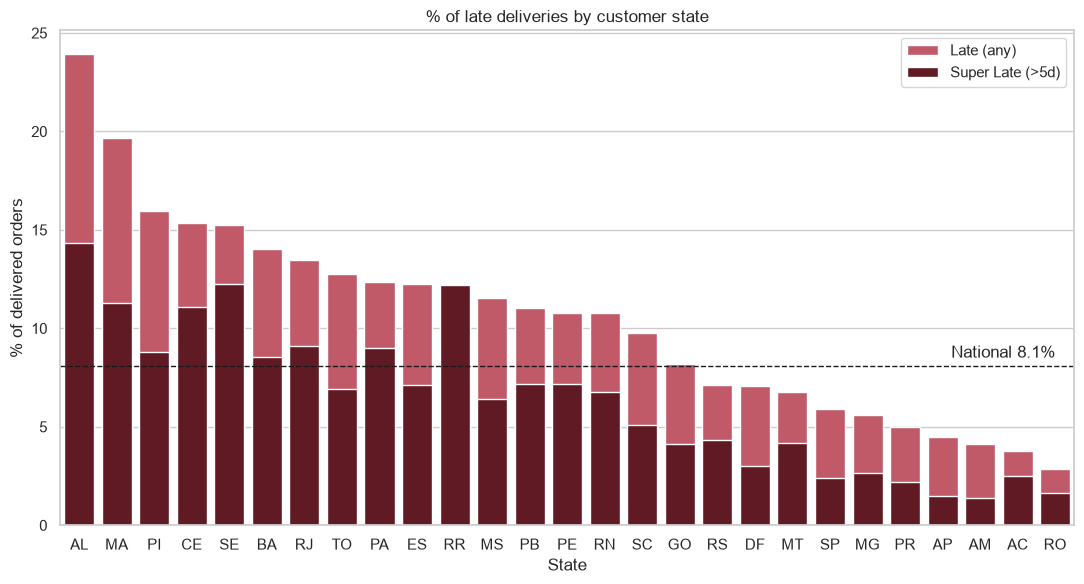

,customer_state,orders,late_pct,super_late_pct,avg_score,median_delay_days
1,AL,397,23.93,14.36,3.85,9.43
9,MA,717,19.67,11.30,3.83,10.01
16,PI,476,15.97,8.82,3.99,13.08
5,CE,1279,15.32,11.10,3.94,12.27
24,SE,335,15.22,12.24,3.91,12.13
4,BA,3256,14.04,8.54,3.93,11.56
18,RJ,12350,13.47,9.09,3.97,12.26
26,TO,274,12.77,6.93,4.15,12.62
13,PA,946,12.37,8.99,3.91,15.08
7,ES,1995,12.23,7.12,4.08,11.15


In [5]:
state = (df.groupby("customer_state")
           .agg(orders=("order_id","count"), late_pct=("is_late","mean"),
                super_late_pct=("delivery_status", lambda s: (s=="Super Late").mean()),
                avg_score=("review_score","mean"), median_delay_days=("Days_Difference","median"))
           .reset_index())
state[["late_pct","super_late_pct"]] *= 100
state = state.sort_values("late_pct", ascending=False)
national = df.is_late.mean()*100
print(f"National late rate: {national:.1f}%")
NE = ["AL","BA","CE","MA","PB","PE","PI","RN","SE"]
print(f"Northeast late rate: {df[df.customer_state.isin(NE)].is_late.mean()*100:.1f}% | rest of Brazil: {df[~df.customer_state.isin(NE)].is_late.mean()*100:.1f}%")

plt.figure(figsize=(11,6))
sns.barplot(data=state, x="customer_state", y="late_pct", color="#d1495b", label="Late (any)")
sns.barplot(data=state, x="customer_state", y="super_late_pct", color="#6b0f1a", label="Super Late (>5d)")
plt.axhline(national, ls="--", c="k", lw=1); plt.text(len(state)-1, national+0.4, f"National {national:.1f}%", ha="right")
plt.title("% of late deliveries by customer state"); plt.ylabel("% of delivered orders"); plt.xlabel("State")
plt.legend(); plt.tight_layout(); plt.show()
state.head(10)

Correlation late % vs km from SP: r = 0.15


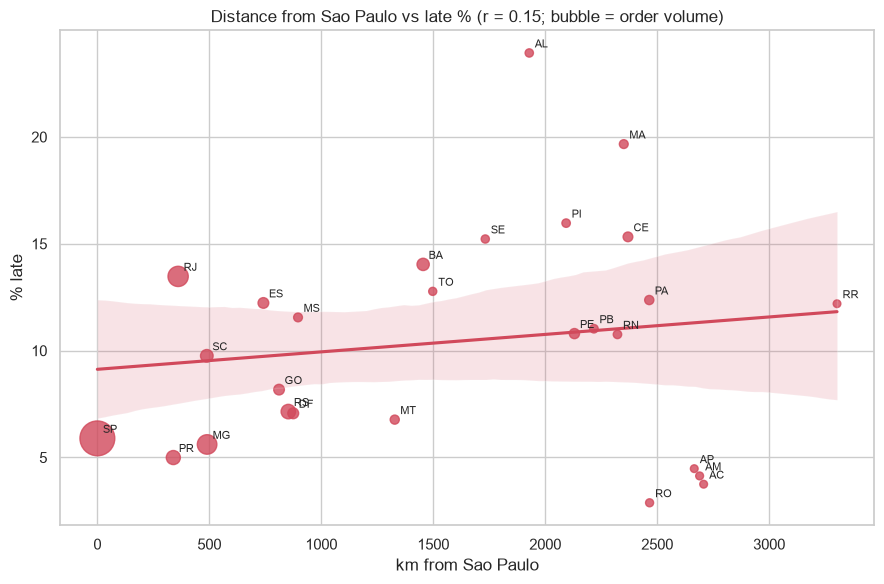

In [6]:
# Remoteness: distance from Sao Paulo (assumed main distribution hub; most sellers are there) using state-capital coordinates
cap = {"SP":(-23.55,-46.63),"RJ":(-22.91,-43.17),"MG":(-19.92,-43.94),"ES":(-20.32,-40.34),"PR":(-25.43,-49.27),
"SC":(-27.59,-48.55),"RS":(-30.03,-51.23),"MS":(-20.44,-54.65),"MT":(-15.60,-56.10),"GO":(-16.68,-49.25),
"DF":(-15.78,-47.93),"BA":(-12.97,-38.51),"SE":(-10.91,-37.07),"AL":(-9.67,-35.74),"PE":(-8.05,-34.88),
"PB":(-7.12,-34.86),"RN":(-5.79,-35.21),"CE":(-3.73,-38.53),"PI":(-5.09,-42.80),"MA":(-2.53,-44.30),
"PA":(-1.46,-48.50),"AP":0.03,"AM":(-3.12,-60.02),"RR":(2.82,-60.67),"AC":(-9.97,-67.81),"RO":(-8.76,-63.90),"TO":(-10.18,-48.33)}
cap["AP"] = (0.03,-51.07)
def hav(a,b):
    la1,lo1,la2,lo2 = map(np.radians,[*a,*b]); h = np.sin((la2-la1)/2)**2+np.cos(la1)*np.cos(la2)*np.sin((lo2-lo1)/2)**2
    return 6371*2*np.arcsin(np.sqrt(h))
state["km_from_SP"] = state.customer_state.map(lambda s: hav(cap["SP"], cap[s]))
r = state[["km_from_SP","late_pct"]].corr().iloc[0,1]

plt.figure(figsize=(9,6))
sns.regplot(data=state, x="km_from_SP", y="late_pct", scatter_kws={"s":state.orders/state.orders.max()*600+30}, color="#d1495b")
for _,row in state.iterrows(): plt.annotate(row.customer_state,(row.km_from_SP,row.late_pct),xytext=(4,4),textcoords="offset points",fontsize=8)
print(f"Correlation late % vs km from SP: r = {r:.2f}")
plt.title(f"Distance from Sao Paulo vs late % (r = {r:.2f}; bubble = order volume)")
plt.xlabel("km from Sao Paulo"); plt.ylabel("% late"); plt.tight_layout(); plt.show()

## Story 4: Sentiment correlation (late delivery -> low reviews)

                 mean  count
delivery_status             
On Time          4.29  88163
Late             3.46   3568
Super Late       1.79   4093


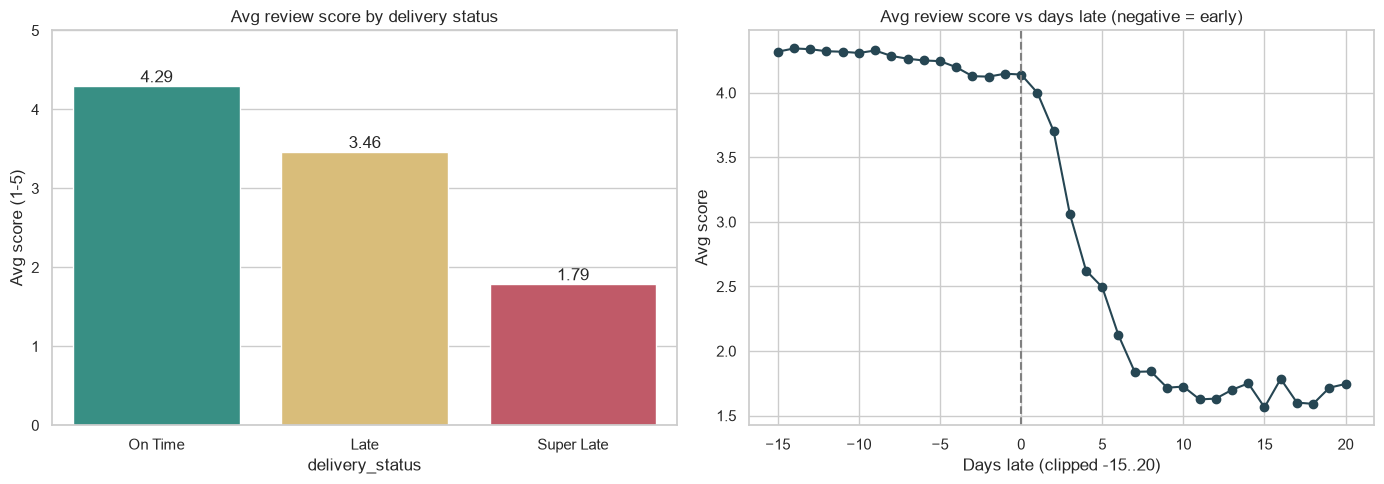

Correlation (days late vs score): -0.267


In [7]:
rv = df.dropna(subset=["review_score"])
by_status = rv.groupby("delivery_status").review_score.agg(["mean","count"]).reindex(["On Time","Late","Super Late"])
print(by_status)

fig,ax = plt.subplots(1,2,figsize=(14,5))
sns.barplot(x=by_status.index, y=by_status["mean"], hue=by_status.index, palette=["#2a9d8f","#e9c46a","#d1495b"], legend=False, ax=ax[0])
for i,v in enumerate(by_status["mean"]): ax[0].text(i, v+0.05, f"{v:.2f}", ha="center")
ax[0].set_ylim(0,5); ax[0].set_title("Avg review score by delivery status"); ax[0].set_ylabel("Avg score (1-5)")

b = rv.assign(delay_bucket=(-rv.Days_Difference).clip(-15,20).round())   # + = days late
curve = b.groupby("delay_bucket").review_score.mean()
ax[1].plot(curve.index, curve.values, marker="o", color="#264653"); ax[1].axvline(0, ls="--", c="grey")
ax[1].set_title("Avg review score vs days late (negative = early)"); ax[1].set_xlabel("Days late (clipped -15..20)"); ax[1].set_ylabel("Avg score")
plt.tight_layout(); plt.show()

print("Correlation (days late vs score):", round((-rv.Days_Difference).corr(rv.review_score),3))

## Bonus: Product categories in English

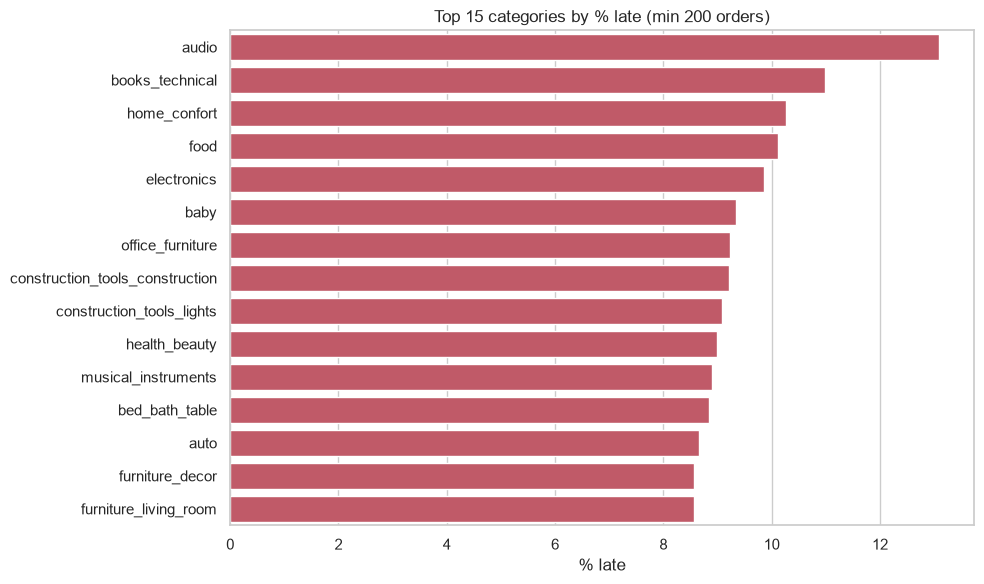

,category_en,orders,late_pct,avg_score,avg_actual_days
4,audio,344,13.08,3.85,13.51
10,books_technical,255,10.98,4.43,10.64
47,home_confort,370,10.27,3.91,13.56
36,food,435,10.11,4.32,9.82
26,electronics,2507,9.85,4.13,12.94
6,baby,2763,9.34,4.12,12.73
57,office_furniture,1246,9.23,3.65,20.70
17,construction_tools_construction,728,9.20,4.13,10.86
18,construction_tools_lights,231,9.09,4.21,9.76
43,health_beauty,8608,8.99,4.24,12.10


In [8]:
cat = (df[df.category_en!="unknown"].groupby("category_en")
         .agg(orders=("order_id","count"), late_pct=("is_late","mean"), avg_score=("review_score","mean"),
              avg_actual_days=("actual_days","mean")).reset_index())
cat["late_pct"] *= 100
cat = cat[cat.orders >= 200].sort_values("late_pct", ascending=False)   # ignore tiny categories
plt.figure(figsize=(10,6)); sns.barplot(data=cat.head(15), y="category_en", x="late_pct", color="#d1495b")
plt.title("Top 15 categories by % late (min 200 orders)"); plt.xlabel("% late"); plt.ylabel(""); plt.tight_layout(); plt.show()
cat.head(10)

## Candidate's Choice: Promise Accuracy Gap
**Why it matters:** the CEO suspects we *over-promise*. Comparing the delivery time we promise with what actually happens per state, and computing the estimate that would have been safe, turns "we are late" into an actionable fix: recalibrate the estimate for the worst states. It also shows whether the problem is slow shipping or bad estimating.

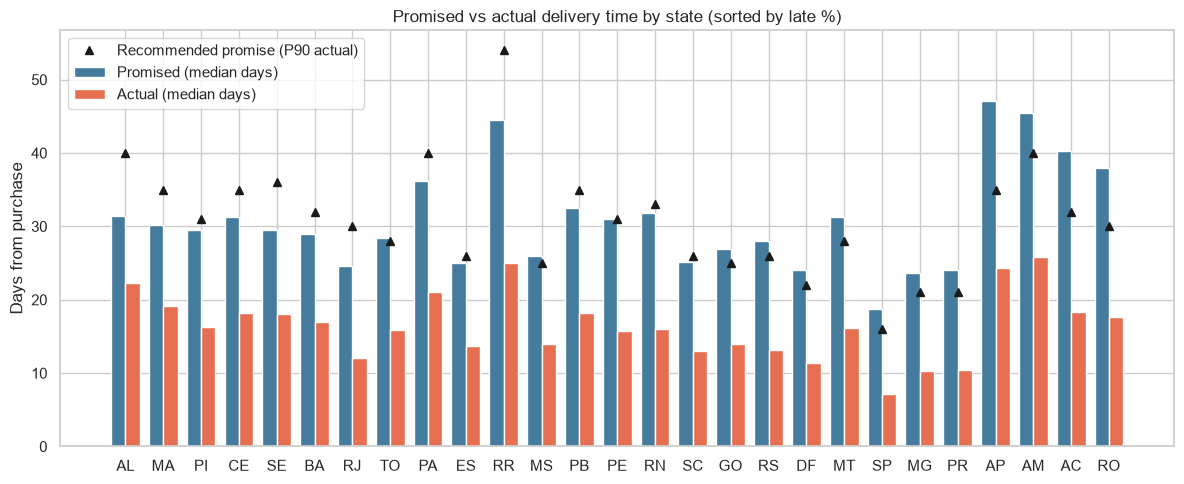

Late rate today: 8.1%  ->  with state-level padded promise: 5.6%
National median promised: 23.2 d | median actual: 10.2 d
States needing extra padding: 13 of 27


,customer_state,orders,promised_median,actual_median,actual_p90,recommended_promise_days,padding_needed_days,late_pct
1,AL,397,31.42,22.33,39.45,40.00,8.58,23.93
9,MA,717,30.19,19.19,34.32,35.00,4.81,19.67
16,PI,476,29.49,16.29,30.07,31.00,1.51,15.97
5,CE,1279,31.25,18.21,34.72,35.00,3.75,15.32
24,SE,335,29.55,18.01,35.46,36.00,6.45,15.22
4,BA,3256,29.01,16.91,31.81,32.00,2.99,14.04
18,RJ,12350,24.61,12.04,29.09,30.00,5.39,13.47
26,TO,274,28.37,15.87,27.95,28.00,0.00,12.77
13,PA,946,36.12,21.08,39.23,40.00,3.88,12.37
7,ES,1995,25.03,13.64,25.35,26.00,0.97,12.23


In [9]:
gap = (df.groupby("customer_state")
         .agg(orders=("order_id","count"), promised_median=("promised_days","median"),
              actual_median=("actual_days","median"), actual_p90=("actual_days",lambda s: s.quantile(.9)))
         .reset_index())
gap["recommended_promise_days"] = np.ceil(gap.actual_p90)          # 90% of orders would arrive within this
gap["padding_needed_days"] = (gap.recommended_promise_days - gap.promised_median).clip(lower=0)   # only ever EXTEND a promise
gap = gap.merge(state[["customer_state","late_pct"]], on="customer_state").sort_values("late_pct", ascending=False)

x = np.arange(len(gap)); w = .38
plt.figure(figsize=(12,5))
plt.bar(x-w/2, gap.promised_median, w, label="Promised (median days)", color="#457b9d")
plt.bar(x+w/2, gap.actual_median,   w, label="Actual (median days)",   color="#e76f51")
plt.plot(x, gap.recommended_promise_days, "k^", label="Recommended promise (P90 actual)")
plt.xticks(x, gap.customer_state); plt.title("Promised vs actual delivery time by state (sorted by late %)")
plt.ylabel("Days from purchase"); plt.legend(); plt.tight_layout(); plt.show()

# What-if: extend the promise ONLY where it is too tight (never shorten a generous one)
p = df.merge(gap[["customer_state","recommended_promise_days"]], on="customer_state")
p["new_promise_days"] = np.maximum(p.promised_days, p.recommended_promise_days)
late_now, late_new = p.is_late.mean()*100, (p.actual_days > p.new_promise_days).mean()*100
print(f"Late rate today: {late_now:.1f}%  ->  with state-level padded promise: {late_new:.1f}%")
print(f"National median promised: {df.promised_days.median():.1f} d | median actual: {df.actual_days.median():.1f} d")
print("States needing extra padding:", (gap.padding_needed_days > 0).sum(), "of", len(gap))
gap

## Export data for the dashboard

In [10]:
df_out = df[["order_id","customer_state","category_en","order_purchase_timestamp","promised_days","actual_days",
             "Days_Difference","delivery_status","review_score"]]
df_out.to_csv("dashboard_orders.csv", index=False)
state.merge(gap[["customer_state","promised_median","actual_median","recommended_promise_days","padding_needed_days"]], on="customer_state").to_csv("state_summary.csv", index=False)
cat.to_csv("category_summary.csv", index=False)
print("Saved dashboard_orders.csv, state_summary.csv, category_summary.csv")

Saved dashboard_orders.csv, state_summary.csv, category_summary.csv


## Key findings 

1.National late rate: 8.1% (Super Late: 4.4%)
2.Worst states: Alagoas (23.9%), Maranhao (19.7%), Piaui (16.0%); 3.Northeast overall 14.3% vs 7.5% for the rest of Brazil.    Correlation of late % with distance from Sao Paulo: r = 0.15 (weak - the Northeast/Rio pattern is not explained by raw distance)
4.Avg review score: On Time 4.29 vs Late 3.46 vs Super Late 1.79
5.Promise gap: national median promised 23 days vs 10 actual (over-padded on average), but 13 states (incl. Alagoas, Maranhao, Ceara, Sergipe, Bahia, Rio de Janeiro) are under-padded; extending the promise only in those states cuts the late rate from 8.1% to 5.6%